<a href="https://colab.research.google.com/github/DulaniDeSilva/Computer-Vision/blob/main/hybrid_images.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/hybridimage/cat.bmp
/kaggle/input/hybridimage/dog.bmp
/kaggle/input/hybridimage/plane.bmp
/kaggle/input/hybridimage/motorcycle.bmp
/kaggle/input/hybridimage/bird.bmp
/kaggle/input/hybridimage/submarine.bmp
/kaggle/input/hybridimage/bicycle.bmp
/kaggle/input/hybridimage/fish.bmp


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

low pass radius: 15 high pass radius:100 || low pass radius: 15 high pass radius:100


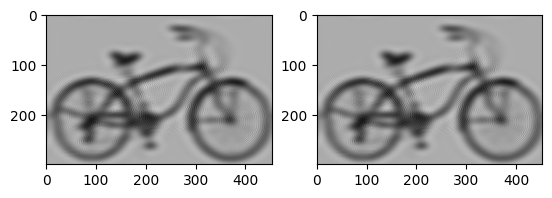

low pass radius: 15 high pass radius:90 || low pass radius: 15 high pass radius:110


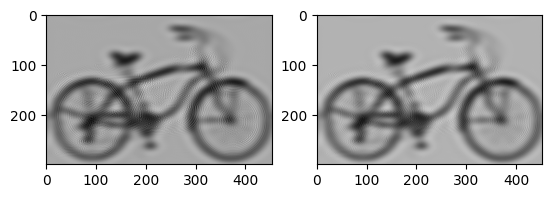

low pass radius: 15 high pass radius:80 || low pass radius: 15 high pass radius:120


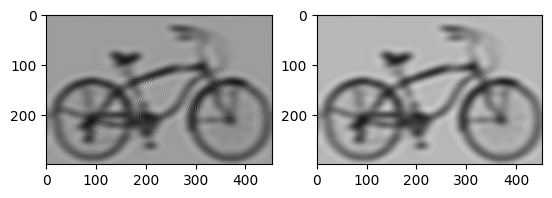

low pass radius: 15 high pass radius:70 || low pass radius: 15 high pass radius:130


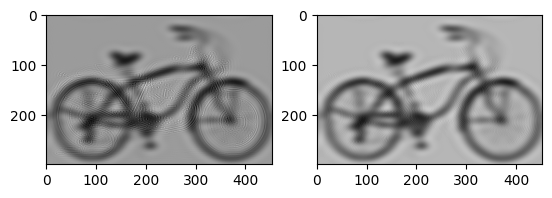

low pass radius: 15 high pass radius:60 || low pass radius: 15 high pass radius:140


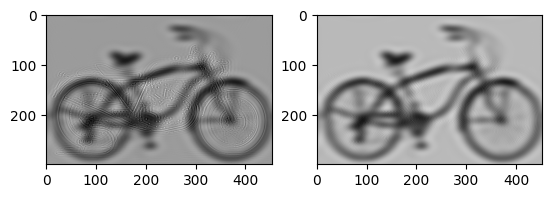

low pass radius: 15 high pass radius:50 || low pass radius: 15 high pass radius:150


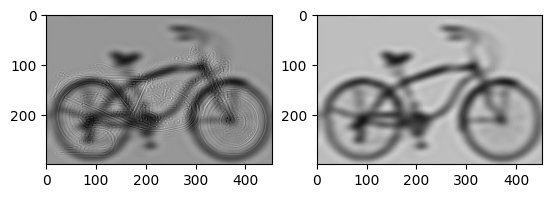

low pass radius: 15 high pass radius:40 || low pass radius: 15 high pass radius:160


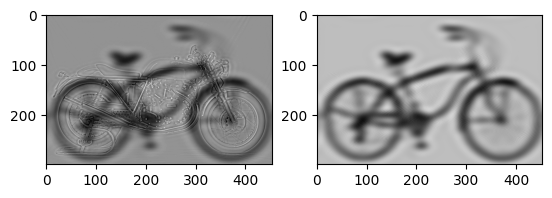

low pass radius: 15 high pass radius:30 || low pass radius: 15 high pass radius:170


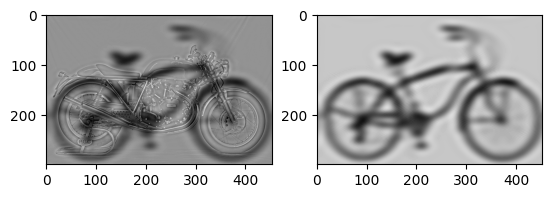

low pass radius: 15 high pass radius:20 || low pass radius: 15 high pass radius:180


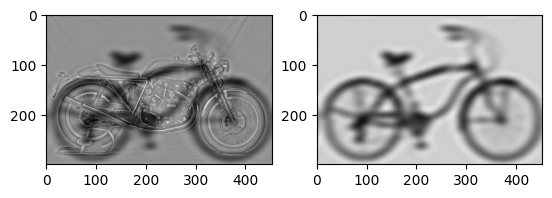

low pass radius: 15 high pass radius:10 || low pass radius: 15 high pass radius:190


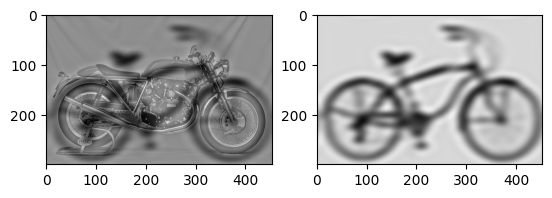

In [ ]:
def load_and_preprocess_images(image1_path, image2_path):
    img1 = cv2.imread(image1_path, cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(image2_path, cv2.IMREAD_GRAYSCALE)

    # Resize images to the same dimensions
    min_height = min(img1.shape[0], img2.shape[0])
    min_width = min(img1.shape[1], img2.shape[1])
    img1 = cv2.resize(img1, (min_width, min_height))
    img2 = cv2.resize(img2, (min_width, min_height))

    return img1, img2

def create_circle_mask(shape, radius):
    mask = np.zeros(shape, dtype=np.uint8)
    cy, cx = shape[0] // 2, shape[1] // 2
    cv2.circle(mask, (cx, cy), radius, (255, 255, 255), -1)
    mask = mask / 255.0
    return mask

def apply_fourier_transform(img):
    f_transform = np.fft.fft2(img)
    f_shift = np.fft.fftshift(f_transform)
    return f_shift

def apply_inverse_fourier_transform(f_shift):
    f_ishift = np.fft.ifftshift(f_shift)
    img_back = np.fft.ifft2(f_ishift)
    img_back = np.abs(img_back)
    return img_back

def apply_low_pass_filter(f_shift, radius,gain=1):
    shape = f_shift.shape
    mask_lp = create_circle_mask(shape, radius)
    mask_lp = cv2.GaussianBlur(mask_lp, (19, 19), 0)
    f_shift_lp = np.multiply(f_shift, mask_lp) * gain
    return f_shift_lp, mask_lp

def apply_high_pass_filter(f_shift, radius,gain=1):
    shape = f_shift.shape
    mask_lp = create_circle_mask(shape, radius)
    mask_lp = cv2.GaussianBlur(mask_lp, (19, 19), 0)
    mask_hp = 1 - mask_lp
    f_shift_hp = np.multiply(f_shift, mask_hp) * gain
    return f_shift_hp, mask_hp

def create_hybrid_image(image1_path, image2_path, low_radius, high_radius):
    # Load and preprocess images
    img1, img2 = load_and_preprocess_images(image1_path, image2_path)

    # Apply Fourier Transform
    f_shift1 = apply_fourier_transform(img1)
    f_shift2 = apply_fourier_transform(img2)

    # Apply filters
    f_shift_lp, mask_lp = apply_low_pass_filter(f_shift1, low_radius,gain=2)
    f_shift_hp, mask_hp = apply_high_pass_filter(f_shift2, high_radius,gain=2)

    lp_image = apply_inverse_fourier_transform(f_shift_lp)
    hp_image = apply_inverse_fourier_transform(f_shift_hp)

    # Combine filtered images
    f_shift_combined = f_shift_lp + f_shift_hp

    # Apply Inverse Fourier Transform
    hybrid_image = apply_inverse_fourier_transform(f_shift_combined)

    return img1, img2, mask_lp, mask_hp, hybrid_image, lp_image, hp_image

def display_results(img1, img2, mask_lp, mask_hp, hybrid_image,lp_image, hp_image):
    plt.figure(figsize=(30, 10))

    plt.subplot(231), plt.imshow(img1, cmap='gray')
    plt.title('Original Image 1'), plt.axis('off')

    plt.subplot(232), plt.imshow(img2, cmap='gray')
    plt.title('Original Image 2'), plt.axis('off')

    plt.subplot(233), plt.imshow(hybrid_image, cmap='gray')
    plt.title('Hybrid Image'), plt.axis('off')

    plt.subplot(234), plt.imshow(lp_image, cmap='gray')
    plt.title('processed Image1'), plt.axis('off')

    plt.subplot(235), plt.imshow(hp_image, cmap='gray')
    plt.title('processed Image2'), plt.axis('off')

    plt.tight_layout()
    plt.show()

# Example usage
image1_path = '/kaggle/input/hybridimage/bicycle.bmp'
image2_path = '/kaggle/input/hybridimage/motorcycle.bmp'
low_radius = 25  # Adjust as needed
high_radius = 25  # Adjust as needed

img1, img2, mask_lp, mask_hp, hybrid_image, lp_image, hp_image = create_hybrid_image(image1_path, image2_path, low_radius, high_radius)
# display_results(img1, img2, mask_lp, mask_hp, hybrid_image, lp_image, hp_image)


low_radius = 15  # Adjust as needed
high_radius = 100  # Adjust as needed

for i in range(0,100
               ,10):
    img1, img2, mask_lp, mask_hp, hybrid_image, lp_image, hp_image = create_hybrid_image(image1_path, image2_path, low_radius, high_radius-i)
    img1, img2, mask_lp, mask_hp, hybrid_image_, lp_image, hp_image = create_hybrid_image(image1_path, image2_path, low_radius, high_radius+i)
    print(f"low pass radius: {low_radius} high pass radius:{high_radius-i} || low pass radius: {low_radius} high pass radius:{high_radius+i}")
    plt.subplot(121)
    plt.imshow(hybrid_image,cmap='gray')
    plt.subplot(122)
    plt.imshow(hybrid_image_,cmap='gray')
    plt.show()




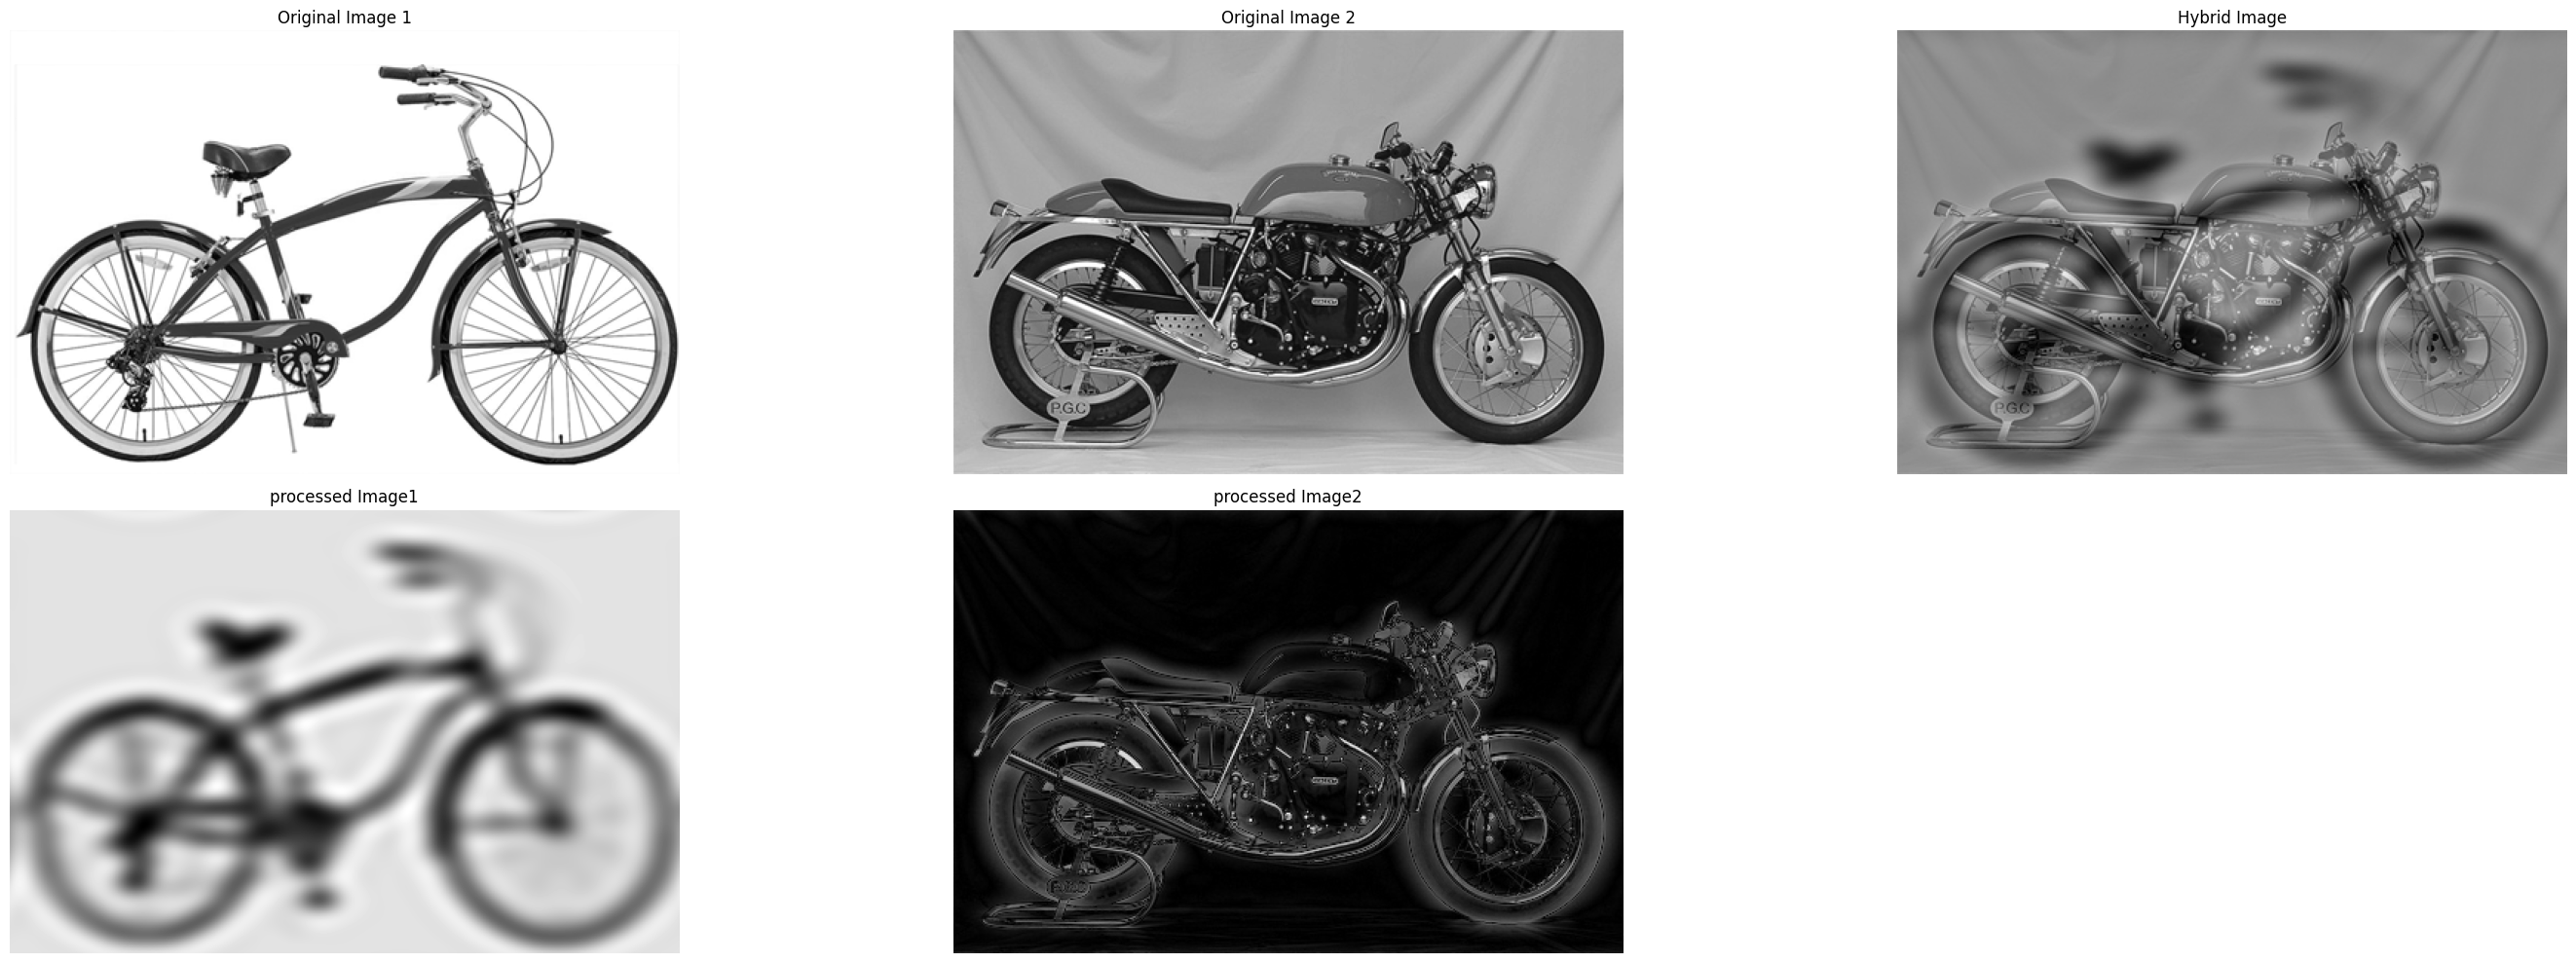

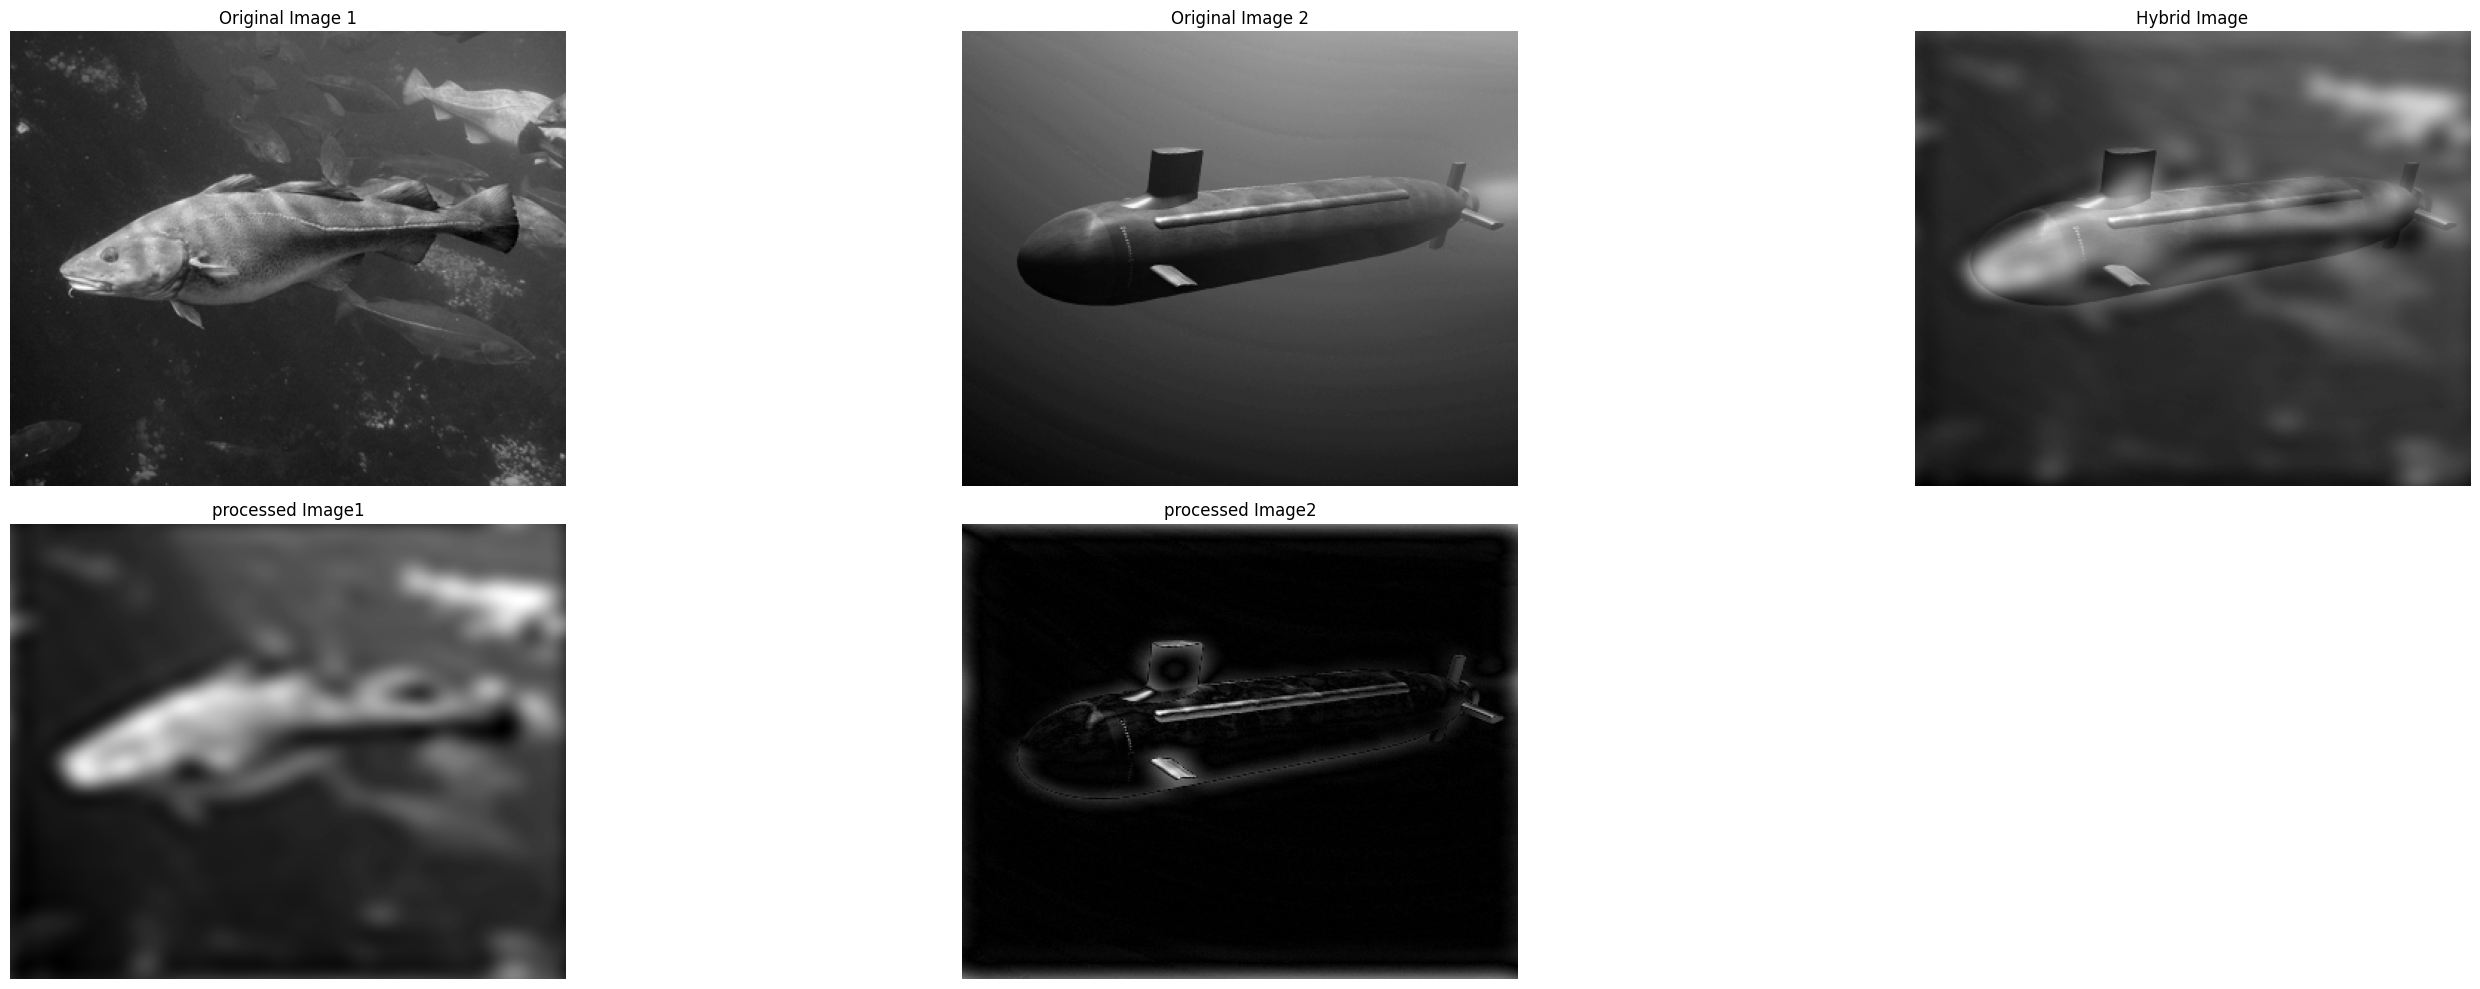

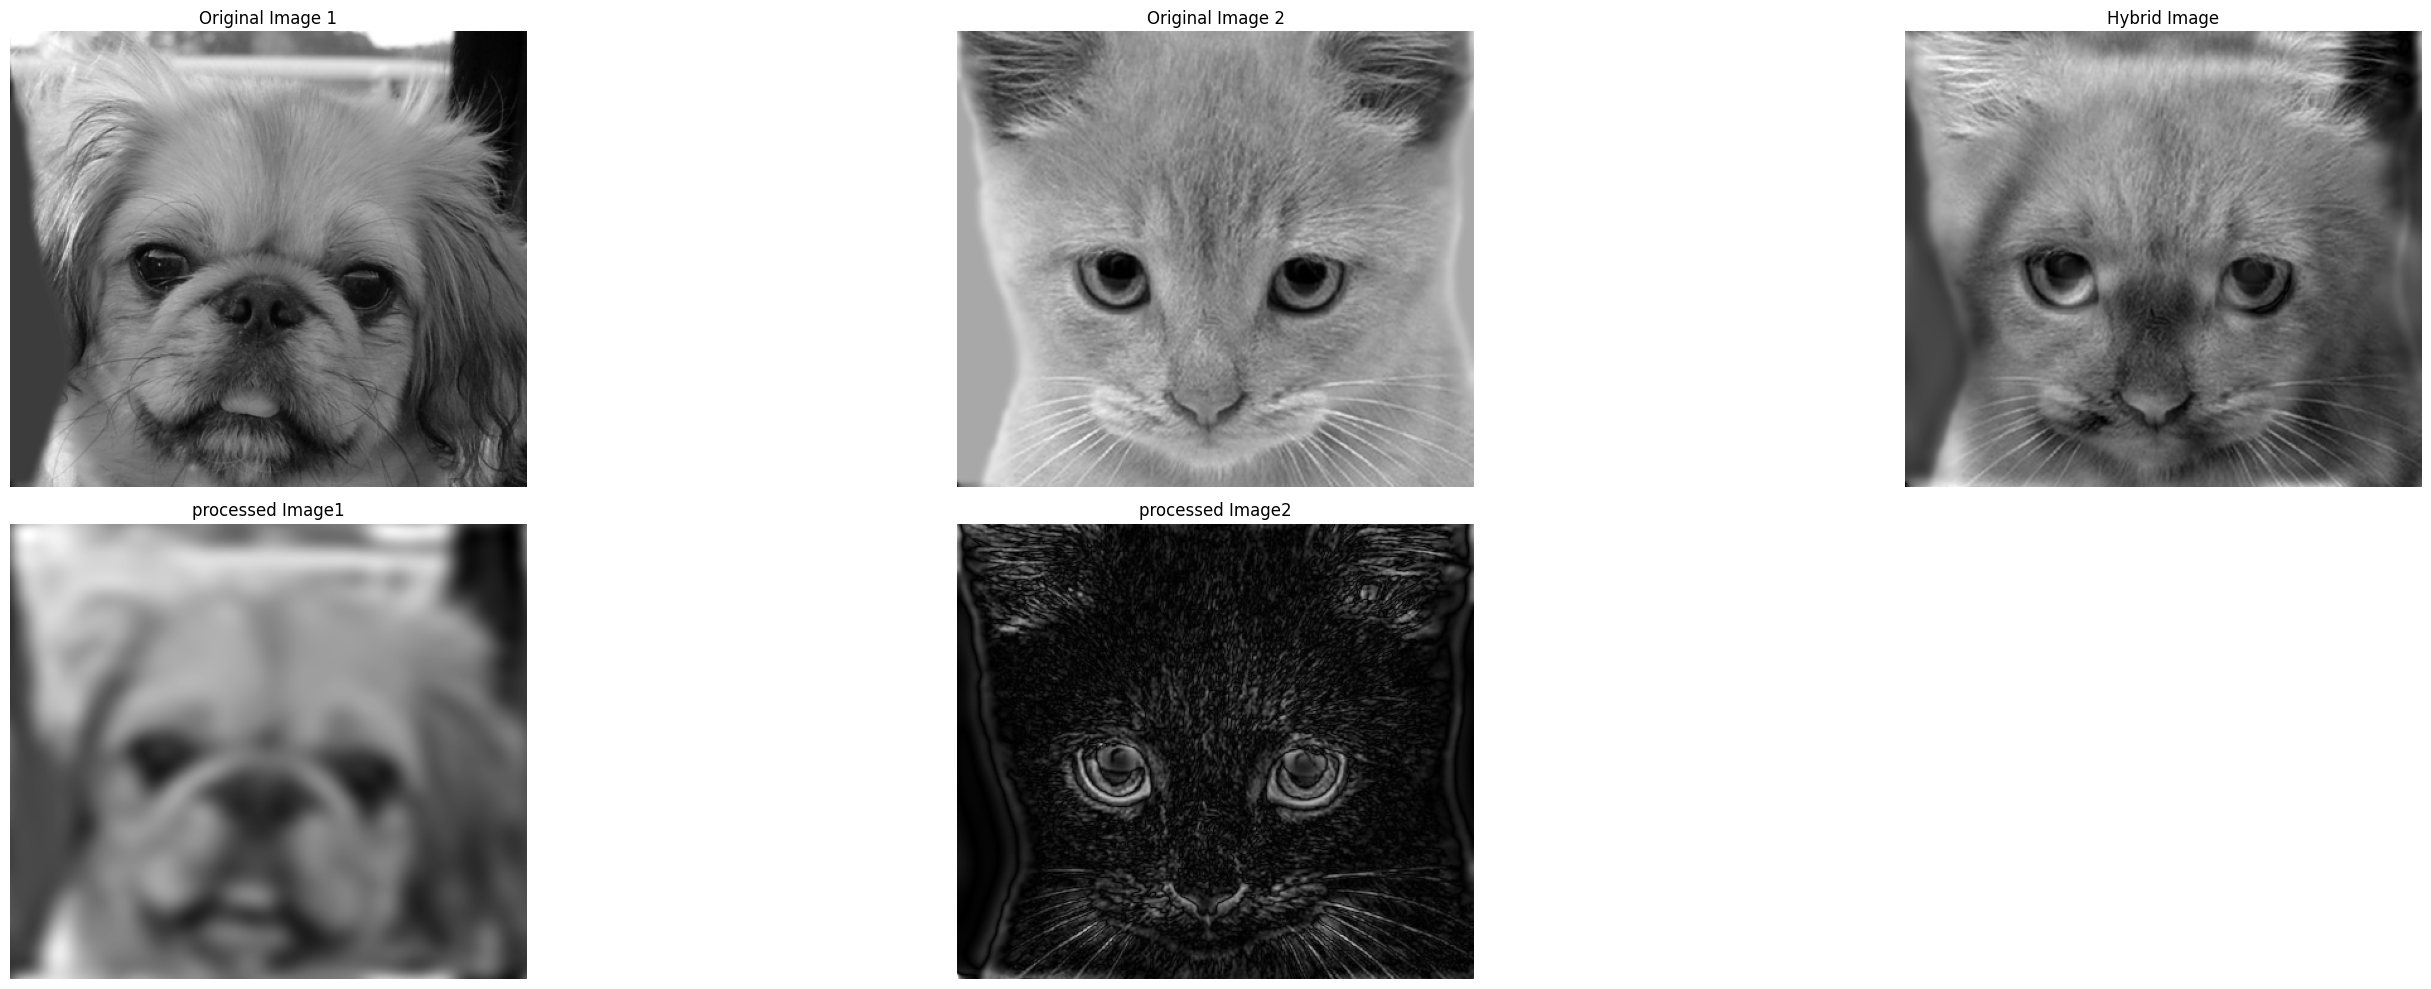

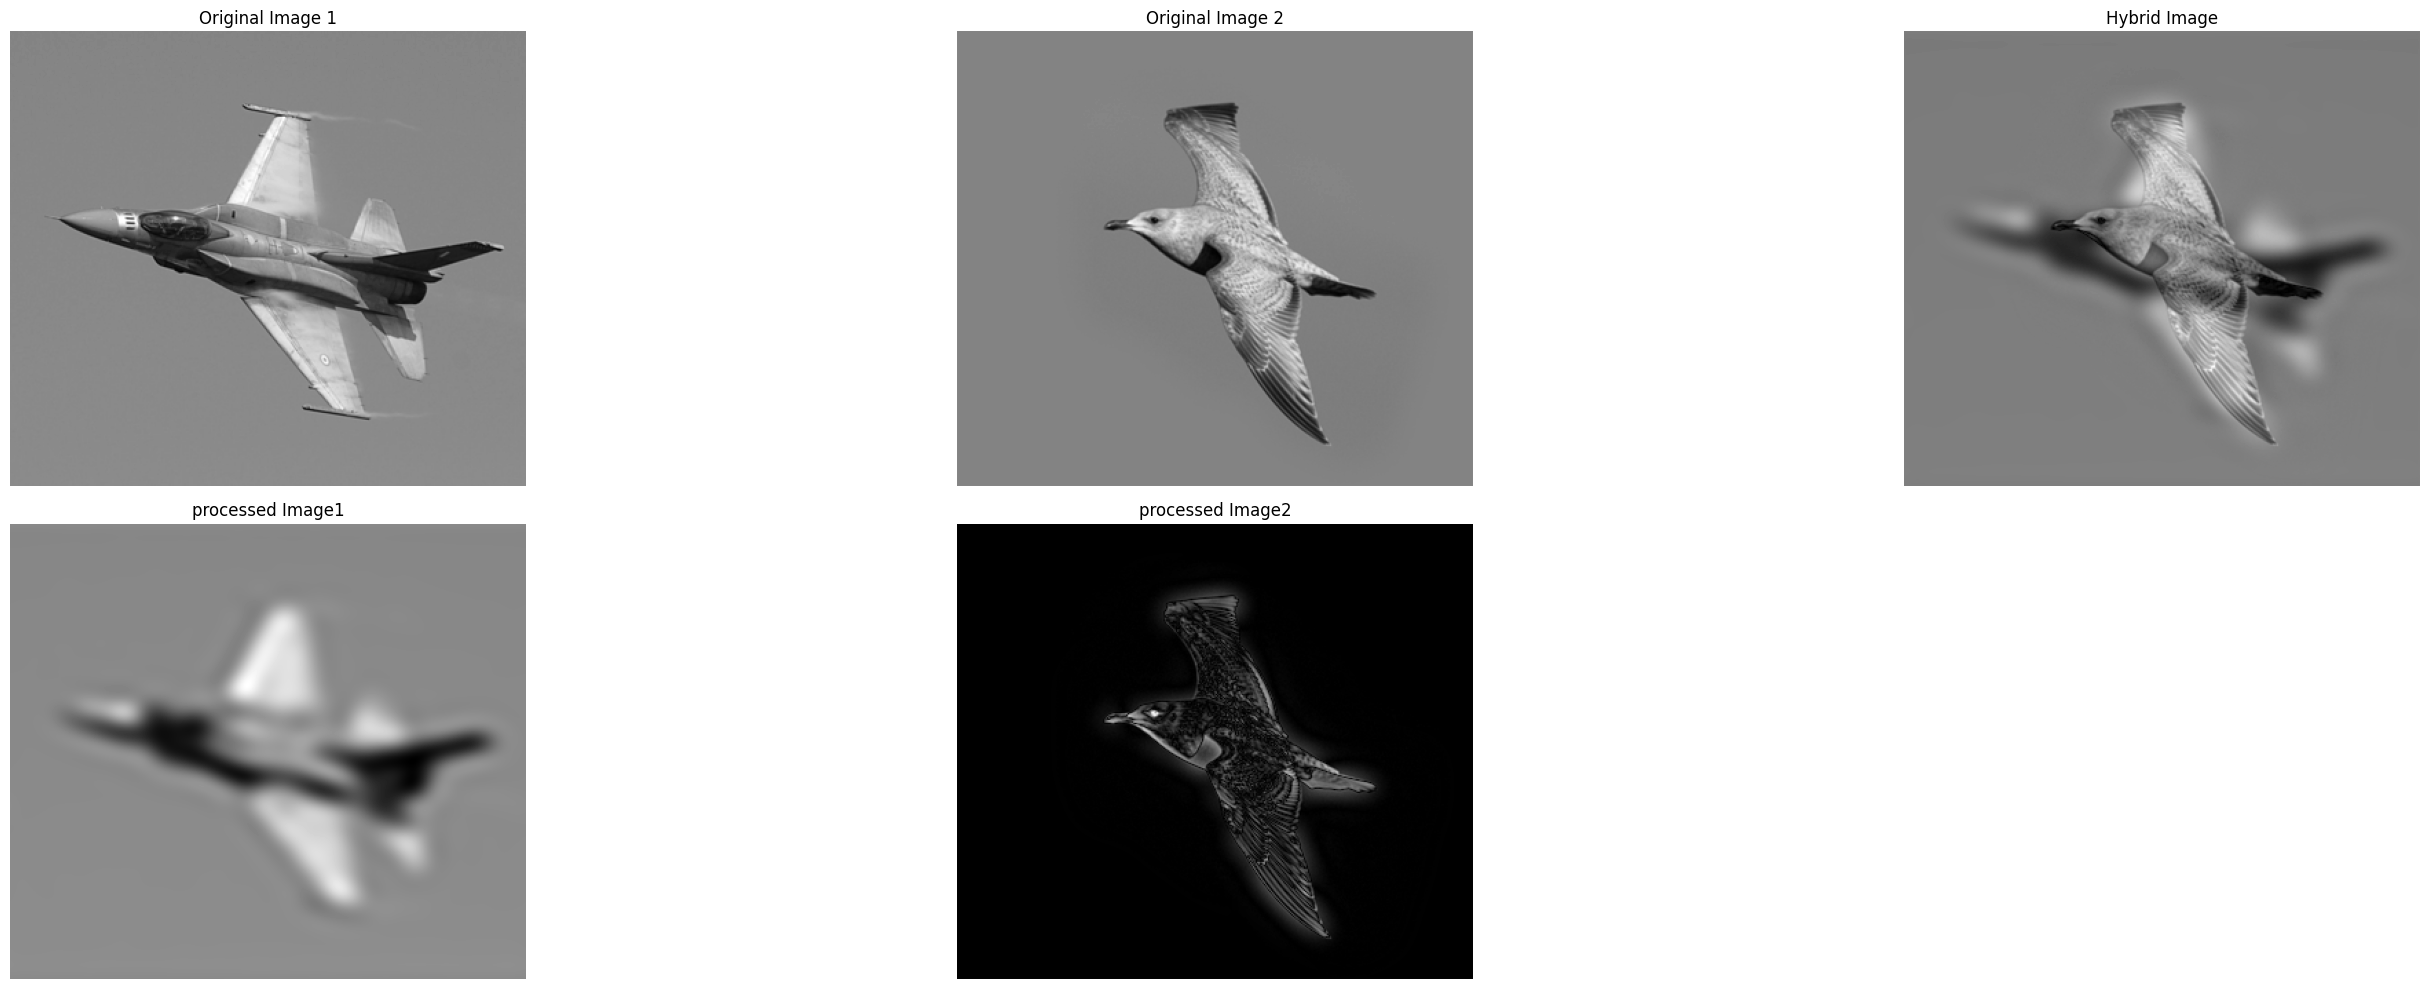

In [ ]:
images = [('bicycle.bmp','motorcycle.bmp'),('fish.bmp','submarine.bmp'),('dog.bmp','cat.bmp'),('plane.bmp','bird.bmp'),]

path = '/kaggle/input/hybridimage'

for image1_path,image2_path in images:
    image1_path = os.path.join(path,image1_path)
    image2_path = os.path.join(path,image2_path)
    low_radius = 15  # Adjust as needed
    high_radius = 10  # Adjust as needed

    img1, img2, mask_lp, mask_hp, hybrid_image, lp_image, hp_image = create_hybrid_image(image1_path, image2_path, low_radius, high_radius)
    display_results(img1, img2, mask_lp, mask_hp, hybrid_image, lp_image, hp_image)


(-0.5, 374.5, 330.5, -0.5)

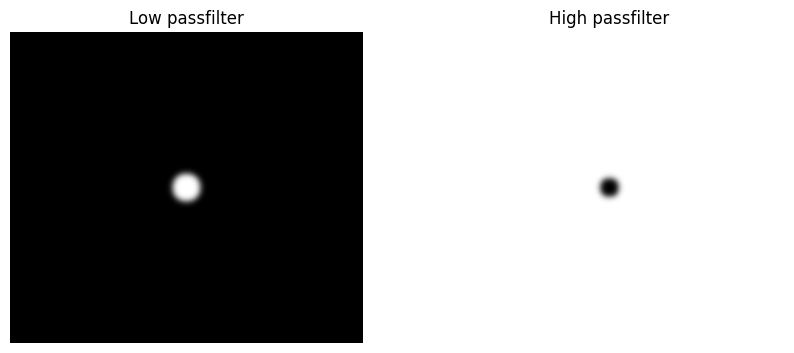

In [ ]:
plt.figure(figsize=(10,10))

plt.subplot(121)
plt.title('Low passfilter')
plt.imshow(mask_lp,cmap='gray')
plt.axis('off')

plt.subplot(122)
plt.title('High passfilter')
plt.imshow(mask_hp,cmap='gray')
plt.axis('off')
